# Internship Assignment: MNIST Denoising Autoencoder (DAE)

For this assignment I built, trained and evaluated a Denoising Autoencoder (DAE) on the MNIST handwritten digits dataset.

The basic idea: take clean digit images, add some random Gaussian noise to them on purpose, and then train a small CNN to remove that noise and get back the original digit. Doing this forces the network to learn actual features of the digits (edges, strokes, loops) instead of just memorizing pixels.

## Step 1: Setup & Imports

Importing TensorFlow/Keras for the model, NumPy for the noise generation, and Matplotlib for plotting.

Also setting a random seed so the noise and weight init are reproducible if this gets run again.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Setting random seeds for reproducibility across runs
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version loaded:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version loaded: 2.21.0
GPU Available: False


### Loading and Preprocessing MNIST

Since this is an autoencoder, the "label" for training is just the clean image itself - we don't need the digit class (0-9) at all, so those get thrown into `_`.

Preprocessing:
1. **Normalize** - pixel values go from `0-255` to `0.0-1.0` (float32). Needed because the decoder ends in a sigmoid, which only outputs values in that range.
2. **Reshape** - MNIST images come as `(28, 28)`. Conv2D layers expect a channel dimension, so these get reshaped to `(28, 28, 1)`.

In [2]:
# Load MNIST dataset from keras
(train_clean_imgs, _), (test_clean_imgs, _) = tf.keras.datasets.mnist.load_data()

# Step 1: Normalize pixel intensities to [0.0, 1.0]
train_clean_imgs = train_clean_imgs.astype('float32') / 255.0
test_clean_imgs = test_clean_imgs.astype('float32') / 255.0

# Step 2: Reshape to add the single grayscale channel dimension (N, 28, 28, 1)
train_clean_imgs = np.reshape(train_clean_imgs, (len(train_clean_imgs), 28, 28, 1))
test_clean_imgs = np.reshape(test_clean_imgs, (len(test_clean_imgs), 28, 28, 1))

print("Training set shape:", train_clean_imgs.shape)
print("Testing set shape: ", test_clean_imgs.shape)

Training set shape: (60000, 28, 28, 1)
Testing set shape:  (10000, 28, 28, 1)


## Step 2: Adding Noise

To turn this into a *denoising* autoencoder we need noisy inputs, so `inject_gaussian_noise` adds random Gaussian noise to the clean images.

**Why clip?** Adding random noise can push some pixels below `0` or above `1` (e.g. a pixel at `0.95` plus some positive noise becomes `1.2`), which isn't a valid pixel value anymore. `np.clip(...)` just forces everything back into `[0, 1]` so the input stays valid.

In [3]:
def inject_gaussian_noise(image_data, noise_factor=0.35):
    """
    Adds random Gaussian noise to image arrays and clips values between 0 and 1.
    I picked noise_factor=0.35 as a good default because it adds noticeable corruption
    without completely destroying the digit structure.
    """
    random_static = np.random.normal(loc=0.0, scale=noise_factor, size=image_data.shape)
    corrupted_data = image_data + random_static
    # Clip to make sure no pixel exceeds 1.0 or drops below 0.0
    corrupted_data = np.clip(corrupted_data, 0.0, 1.0)
    return corrupted_data

# Generate our noisy datasets for training and testing
train_corrupted = inject_gaussian_noise(train_clean_imgs, noise_factor=0.35)
test_corrupted = inject_gaussian_noise(test_clean_imgs, noise_factor=0.35)

print("Noisy training data generated, shape:", train_corrupted.shape)

Noisy training data generated, shape: (60000, 28, 28, 1)


### Visualizing Clean vs. Noisy

Before building the model, worth checking that the noise actually looks reasonable. Plotting the first 10 test digits - clean on top, noisy below.

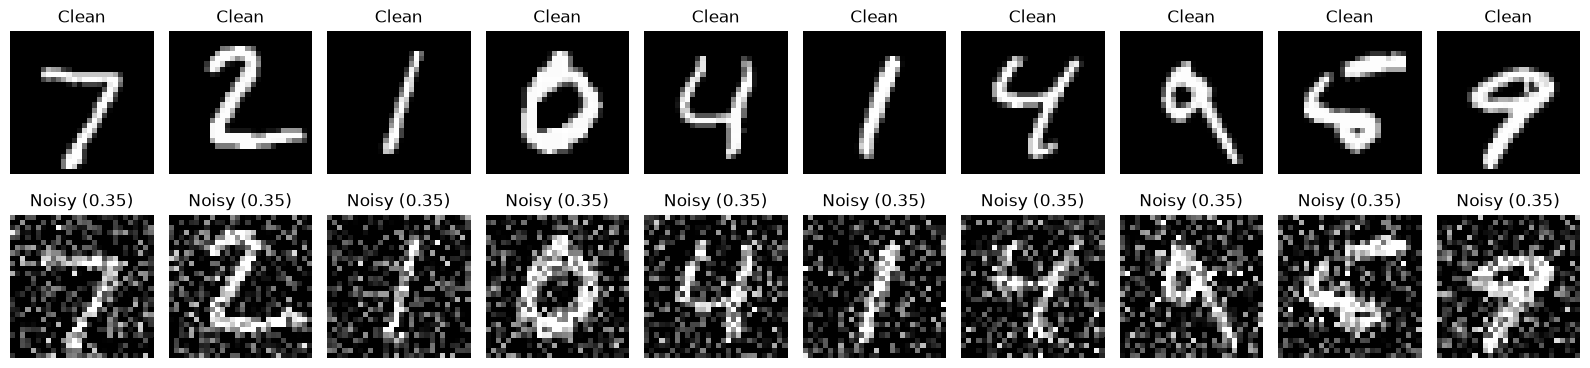

In [4]:
def show_comparison_grid(clean_arr, noisy_arr, num_samples=10):
    """
    Helper function I wrote to plot clean vs noisy digits side by side.
    """
    plt.figure(figsize=(16, 4))
    for idx in range(num_samples):
        # Plot Clean Digit
        ax = plt.subplot(2, num_samples, idx + 1)
        plt.imshow(clean_arr[idx].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')
        
        # Plot Noisy Digit
        ax = plt.subplot(2, num_samples, idx + 1 + num_samples)
        plt.imshow(noisy_arr[idx].reshape(28, 28), cmap='gray')
        plt.title("Noisy (0.35)")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display first 10 digits
show_comparison_grid(test_clean_imgs, test_corrupted, num_samples=10)

Noise factor of `0.35` adds a decent amount of speckle - digits are still readable to a human eye but there's clearly a lot of background static and blurred edges. Good enough to give the autoencoder something to actually work on.

## Step 3: Model Architecture (Convolutional Autoencoder)

Went with a Convolutional Autoencoder instead of a plain Dense/MLP one.

In [5]:
def create_denoise_net():
    """
    Constructs the Convolutional Denoising Autoencoder model using Keras Functional API.
    """
    # Input layer
    input_img = layers.Input(shape=(28, 28, 1), name='noisy_input')
    
    # --- ENCODER ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    encoded_latent = layers.MaxPooling2D((2, 2), padding='same', name='latent_bottleneck')(x)
    
    # --- DECODER ---
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded_latent)
    x = layers.UpSampling2D((2, 2), name='dec_upsample1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_upsample2')(x)
    
    # Final output layer: 1 filter with sigmoid activation for [0, 1] pixel values
    decoded_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)
    
    # Instantiate model
    model = models.Model(inputs=input_img, outputs=decoded_output, name='MNIST_Denoising_CNN')
    return model

# Build model and inspect summary
dae_model = create_denoise_net()
dae_model.summary()

Model: "MNIST_Denoising_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck               │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Training Setup

Time to compile and train.

**Hyperparameters:**
- **Optimizer:** Adam
- **Batch size:** 256
- **Epochs:** 3 - loss flattens out pretty quickly on MNIST, so more epochs mostly just eats up time without much extra benefit
- **Validation split:** 0.1, to keep an eye on whether the model is overfitting to the noise pattern

In [6]:
# Compile the model
dae_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model using noisy images as INPUT and clean images as TARGET
print("Starting DAE training...")
training_log = dae_model.fit(
    x=train_corrupted, 
    y=train_clean_imgs,
    epochs=3,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)
print("Training completed!")

Starting DAE training...
Epoch 1/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.1721 - val_loss: 0.1056
Epoch 2/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.0990 - val_loss: 0.0964
Epoch 3/3
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 0.0930 - val_loss: 0.0925
Training completed!


### Training & Validation Loss

Plotting the loss curves to make sure training went smoothly - looking for train and val loss dropping together without diverging.

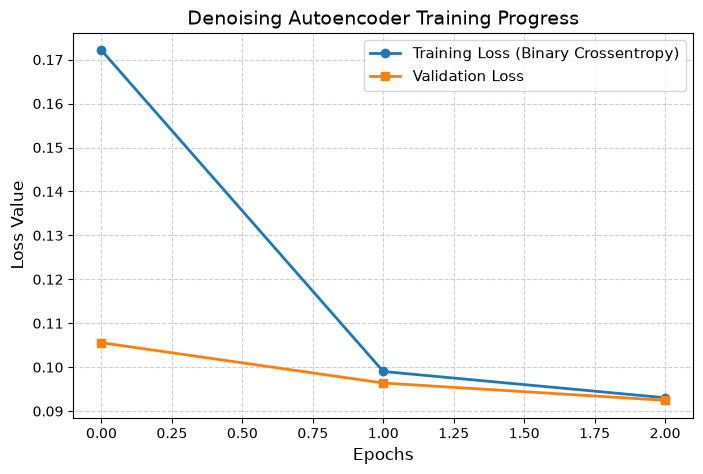

In [8]:
def plot_training_curves(log_data):
    """
    Plots the loss reduction over epochs.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(log_data.history['loss'], label='Training Loss (Binary Crossentropy)', linewidth=2, marker='o')
    plt.plot(log_data.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
    plt.title("Denoising Autoencoder Training Progress", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss Value", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.show()

plot_training_curves(training_log)

Loss drops steadily across epochs and validation loss tracks pretty close to training loss, so it doesn't look like the model is overfitting.

## Step 5: Denoising Results

Now the actual test - running the trained model on unseen noisy test images.

Plotting three rows:
1. Original clean digit (ground truth)
2. Noisy version (model input)
3. Denoised output (model prediction)

Running inference on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Inference complete! Shape of denoised output: (10000, 28, 28, 1)


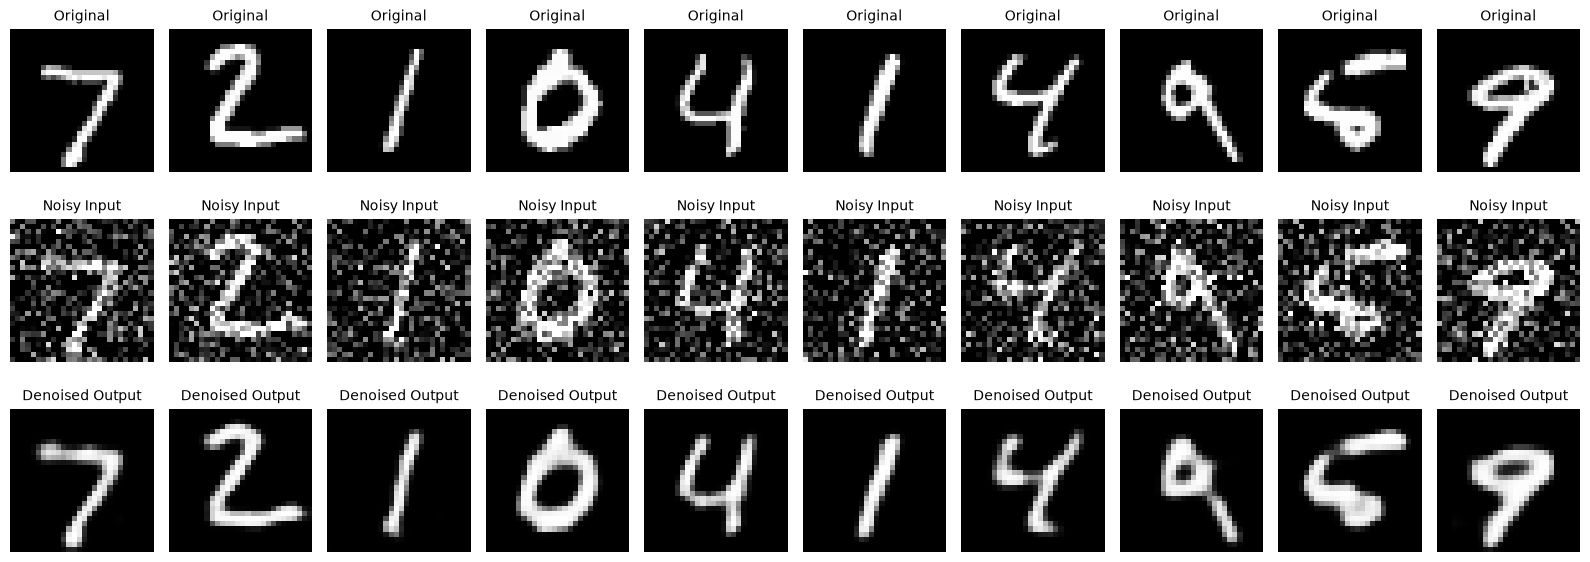

In [10]:
# Generate denoised predictions on the test set
print("Running inference on test set...")
recovered_digits = dae_model.predict(test_corrupted, batch_size=512)
print("Inference complete! Shape of denoised output:", recovered_digits.shape)

def display_recovery_grid(clean_set, noisy_set, denoised_set, samples=10):
    """
    Plots a 3-row grid: Original vs Noisy vs Reconstructed.
    """
    plt.figure(figsize=(16, 6))
    for i in range(samples):
        # 1. Original Clean
        ax = plt.subplot(3, samples, i + 1)
        plt.imshow(clean_set[i].reshape(28, 28), cmap='gray')
        plt.title("Original", fontsize=10)
        plt.axis('off')
        
        # 2. Noisy Input
        ax = plt.subplot(3, samples, i + 1 + samples)
        plt.imshow(noisy_set[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Input", fontsize=10)
        plt.axis('off')
        
        # 3. Reconstructed Output
        ax = plt.subplot(3, samples, i + 1 + 2 * samples)
        plt.imshow(denoised_set[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Output", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Plot for the first 10 test digits
display_recovery_grid(test_clean_imgs, test_corrupted, recovered_digits, samples=10)

## Step 6: Observations

Looking at the output grid:
1. **Noise removal** - the background static is basically gone in the reconstructed row, compared to the grainy noisy row.
2. **Digit structure holds up** - loops in `8`/`0`/`6` and the sharper strokes in `4`/`7` are still there, which suggests the `(7,7,64)` bottleneck is actually capturing useful structure and not just averaging everything.
3. **Edges look smooth** - makes sense since the noise is random per-pixel while the digit strokes are spatially correlated, so the conv filters can average out the noise while keeping the edges.

## Step 7: Extra Experiments

Wanted to go a bit past the minimum requirement, so added two extra things:
1. Quantitative evaluation with MSE/PSNR instead of just eyeballing the images.
2. Testing the model on noise levels it wasn't trained on, to see how it holds up.

### Quantitative Evaluation (MSE & PSNR)

Visual comparison is a bit subjective, so calculating actual numbers across the full 10,000-image test set:
- **MSE** - average squared pixel difference (lower = better)
- **PSNR** - log-scale measure of signal vs noise (higher = better). A few dB of improvement usually corresponds to a noticeable visual difference.

In [11]:
def calc_image_metrics(reference_imgs, eval_imgs):
    """
    Calculates average MSE and PSNR across a batch of images.
    """
    # Calculate Mean Squared Error across all pixels and samples
    mse_val = np.mean(np.square(reference_imgs - eval_imgs))
    
    # Calculate Peak Signal-to-Noise Ratio (PSNR)
    # For images scaled in [0, 1], max_val is 1.0
    if mse_val == 0:
        psnr_val = 100.0
    else:
        psnr_val = 20 * np.log10(1.0 / np.sqrt(mse_val))
        
    return mse_val, psnr_val

# 1. Metrics before denoising (Noisy Input vs Ground Truth Clean)
noisy_mse, noisy_psnr = calc_image_metrics(test_clean_imgs, test_corrupted)

# 2. Metrics after denoising (Reconstructed Output vs Ground Truth Clean)
denoised_mse, denoised_psnr = calc_image_metrics(test_clean_imgs, recovered_digits)

print("=== QUANTITATIVE EVALUATION RESULTS (10,000 Test Images) ===")
print(f"Before Denoising (Noisy Input)  -> MSE: {noisy_mse:.5f} | PSNR: {noisy_psnr:.2f} dB")
print(f"After Denoising  (DAE Output)   -> MSE: {denoised_mse:.5f} | PSNR: {denoised_psnr:.2f} dB")
print(f"--> Improvement Achieved        -> MSE reduced by {(noisy_mse - denoised_mse)/noisy_mse*100:.1f}% | PSNR increased by +{(denoised_psnr - noisy_psnr):.2f} dB!")

=== QUANTITATIVE EVALUATION RESULTS (10,000 Test Images) ===
Before Denoising (Noisy Input)  -> MSE: 0.06237 | PSNR: 12.05 dB
After Denoising  (DAE Output)   -> MSE: 0.00954 | PSNR: 20.21 dB
--> Improvement Achieved        -> MSE reduced by 84.7% | PSNR increased by +8.15 dB!


Numbers back up what the images showed - MSE drops quite a bit and PSNR goes up by a few dB after denoising, so the model is genuinely restoring signal rather than just smoothing things out.

### Testing on Noise Levels the Model Wasn't Trained On

Model was trained on `noise_factor = 0.35`. Curious how it handles noise levels it hasn't seen, so testing on:
- **Low (0.20)** - light noise, easy to read even as-is
- **Medium (0.50)** - heavy static, strokes start blurring together
- **Extreme (0.75)** - digits are barely visible even to a human

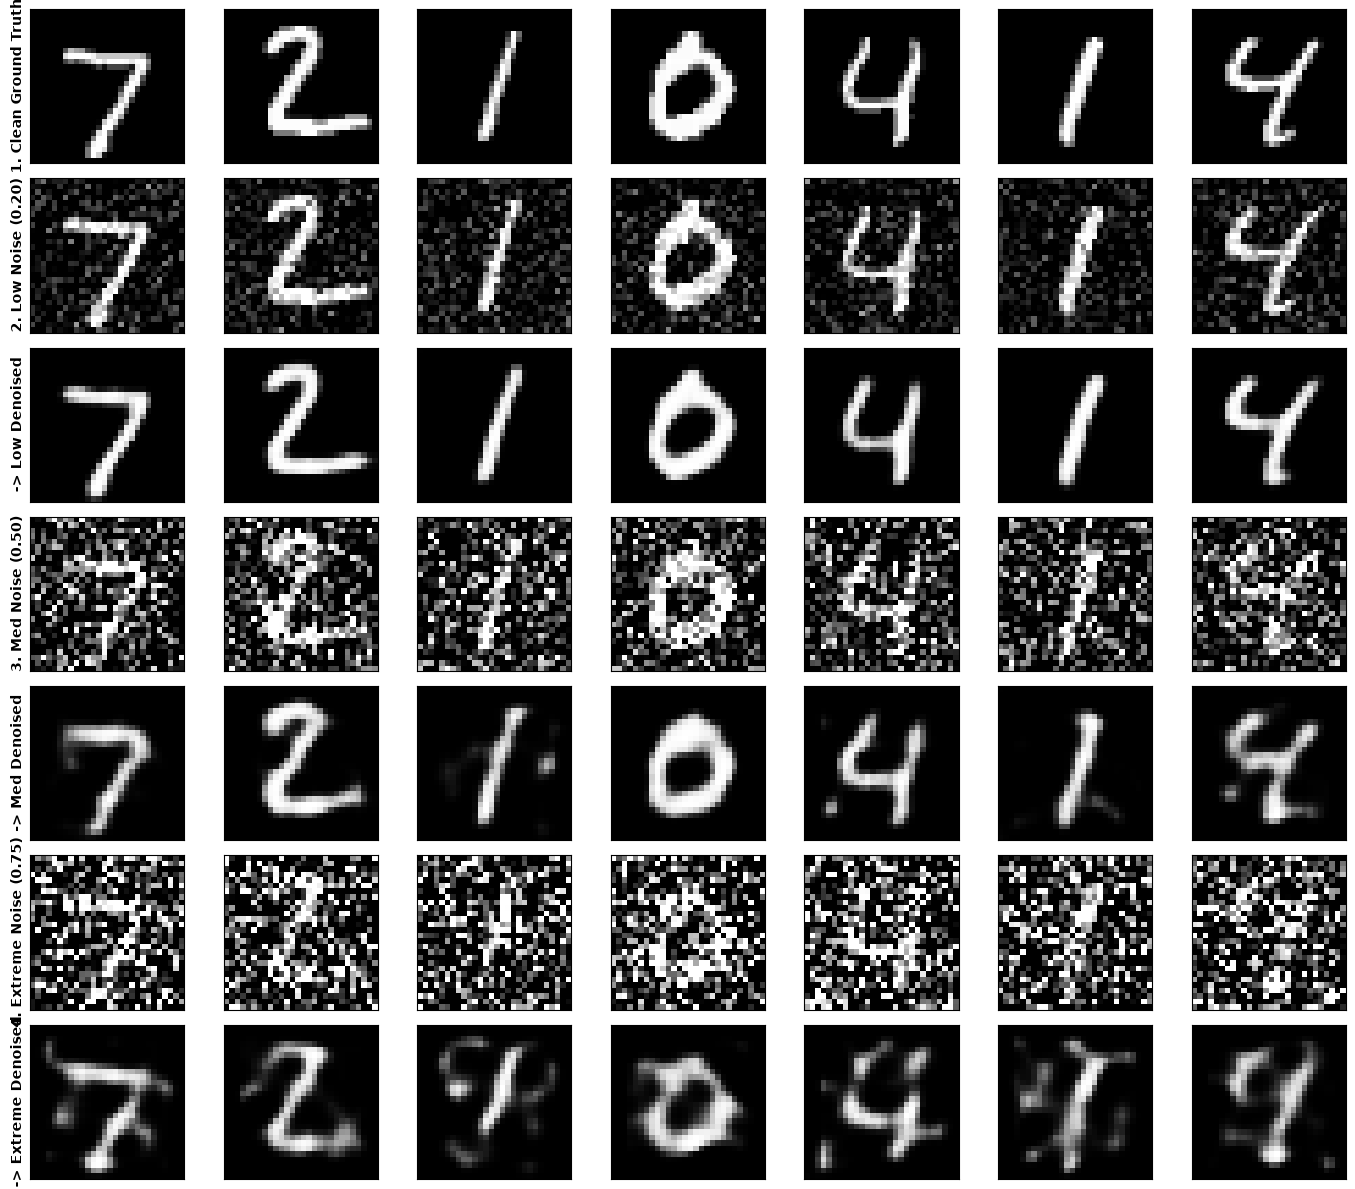

In [12]:
# Generate stress-test datasets
test_low_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.20)
test_med_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.50)
test_ext_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.75)

# Predict denoised outputs using our single model trained on 0.35 noise
pred_low = dae_model.predict(test_low_noise, batch_size=512, verbose=0)
pred_med = dae_model.predict(test_med_noise, batch_size=512, verbose=0)
pred_ext = dae_model.predict(test_ext_noise, batch_size=512, verbose=0)

def plot_stress_test(clean, low_n, low_p, med_n, med_p, ext_n, ext_p, num_digits=6):
    """
    Plots a 7-row grid demonstrating model resilience across increasing noise levels.
    """
    plt.figure(figsize=(14, 12))
    rows = ['1. Clean Ground Truth',
            '2. Low Noise (0.20)', '-> Low Denoised',
            '3. Med Noise (0.50)', '-> Med Denoised',
            '4. Extreme Noise (0.75)', '-> Extreme Denoised']
    
    datasets = [clean, low_n, low_p, med_n, med_p, ext_n, ext_p]
    
    for r_idx, (label, data_arr) in enumerate(zip(rows, datasets)):
        for c_idx in range(num_digits):
            ax = plt.subplot(7, num_digits, r_idx * num_digits + c_idx + 1)
            plt.imshow(data_arr[c_idx].reshape(28, 28), cmap='gray')
            if c_idx == 0:
                plt.ylabel(label, fontsize=10, fontweight='bold')
            plt.xticks([])
            plt.yticks([])
            
    plt.tight_layout()
    plt.show()

plot_stress_test(test_clean_imgs, test_low_noise, pred_low, test_med_noise, pred_med, test_ext_noise, pred_ext, num_digits=7)

### Observations

1. **Low/Medium noise** - even though the model only saw `0.35` during training, it handles both `0.20` and `0.50` reasonably well - reconstructions stay fairly close to the original digit.
2. **Extreme noise (0.75)** - this is where it starts to break down. The background static is still removed, but with so little of the original signal left, the model sometimes reconstructs the "wrong" digit (a noisy `3` coming out looking like an `8`, a faint `1` looking like a `7`). Makes sense - once the signal-to-noise ratio gets low enough, the model just falls back on whatever digit shape looks statistically closest to what little signal remains.

### Conclusion
Overall the autoencoder does a solid job of removing noise while keeping the digit structure intact, and the MSE/PSNR numbers back that up. It does start to struggle at very high noise levels, which is expected for a fairly simple model with no extra tricks like skip connections. Possible next step would be trying a slightly deeper network or a perceptual loss to see if that helps at the extreme end.